In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import os
from torch.utils.data import DataLoader
import seaborn as sns
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import random
import csv

### Chroma Input

In [2]:
class CNNChromagram(nn.Module):
    def __init__(self, input_time = 861):
        super(CNNChromagram, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=(3, 3), padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=(3, 3), padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=(3, 3), padding=1)

        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=(1, 2))

        reduced_time = input_time // 8
        fc_input_size = 128 * 12

        self.fc1 = nn.Linear(fc_input_size, 64)
        self.fc2 = nn.Linear(64, 2)

        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)

        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)

        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)

        batch_size, channels, freq_bins, time_steps = x.shape
        x = x.permute(0, 3, 1, 2)
        x = x.reshape(batch_size, time_steps, -1)

        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [4]:
class ChromaDataset(torch.utils.data.Dataset):
    def __init__(self, audio_dir, window_size = 20, sr = 16000, hop_length = 512, num_classes = 2):
        self.audio_dir = audio_dir
        self.window_frames = window_size * sr // hop_length
        self.sr = sr
        self.num_classes = num_classes
        self.audio_files = [f for f in os.listdir(audio_dir)]

    def __len__(self):
        return len(self.audio_files)

    def extract_chroma(self, file_path):
        y, _ = librosa.load(file_path)
        chroma = librosa.feature.chroma_stft(y = y, sr = 22050)
        return chroma

    def get_label(self, file_name, num_frames):
        label = np.zeros((num_frames, self.num_classes))

        if 'GMjo' in file_name:
            label[:, 0] = 1
        elif 'Ujo' in file_name:
            label[:, 1] = 1
        return label

    def __getitem__(self, idx):
        file_name = self.audio_files[idx]
        file_path = os.path.join(self.audio_dir, file_name)

        chroma = self.extract_chroma(file_path)
        num_frames = chroma.shape[1]

        labels = self.get_label(file_name, num_frames)

        if num_frames < self.window_frames:
            chroma_pad = np.zeros((12, self.window_frames - num_frames))
            chroma = np.concatenate((chroma, chroma_pad), axis = 1)

            label_pad = np.zeros((self.window_frames - num_frames, self.num_classes))
            labels = np.concatenate((labels, label_pad), axis = 0)

        else:
            start_idx = random.randint(0, num_frames - self.window_frames)
            chroma = chroma[:, start_idx:start_idx + self.window_frames]
            labels = labels[start_idx:start_idx + self.window_frames]

        new_T = chroma.shape[1] // 8
        labels  = torch.tensor(labels, dtype = torch.float32).unsqueeze(0)
        labels = F.interpolate(labels.permute(0, 2, 1), size = new_T, mode = 'linear').permute(0, 2, 1).squeeze(0)

        chroma_tensor = torch.tensor(chroma, dtype = torch.float32).unsqueeze(0)
        label_tensor = torch.tensor(labels, dtype = torch.float32)

        return chroma_tensor, label_tensor

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
audio_dir = "/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/Audio/Vocal"

dataset = ChromaDataset(audio_dir, window_size=20, sr= 16000, hop_length=512, num_classes=2)
song_files = dataset.audio_files
loo = LeaveOneOut()
model = CNNChromagram(input_time=dataset.window_frames).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss()

loo_losses = []
loo_accs = []

for train_idx, test_idx in loo.split(song_files):
    train_X, train_y = [], []
    for idx in train_idx:
        chroma, labels = dataset[idx]
        train_X.append(chroma)
        train_y.append(labels)

    val_X, val_y = dataset[test_idx[0]]
    print(val_X.shape, val_y.shape)

    train_X = torch.stack(train_X).to(device)
    train_y = torch.stack(train_y).to(device)
    print(train_X.shape, train_y.shape)

    val_X = val_X.unsqueeze(0).to(device)
    val_y = val_y.unsqueeze(0).to(device)
    print(val_X.shape, val_y.shape)

    train_y = train_y.argmax(dim=-1)
    val_y = val_y.argmax(dim=-1)

    for epoch in range(50):
        optimizer.zero_grad()
        outputs = model(train_X)
        loss = criterion(outputs.permute(0, 2, 1), train_y)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_output = model(val_X)
        val_loss = criterion(val_output.permute(0, 2, 1), val_y)
        pred = torch.argmax(val_output, dim=2)
        accuracy = (pred == val_y).float().mean().item()

    loo_losses.append(val_loss.item())
    loo_accs.append(accuracy)

    print(f"Validation Loss: {val_loss.item():.4f}, Accuracy: {accuracy:.4f}")

print("\n LOO-CV Results")
print(f"Average Validation Loss: {np.mean(loo_losses):.4f}")
print(f"Average Validation Accuracy: {np.mean(loo_accs):.4f}")

/tmp/ipykernel_466491/49127939.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label_tensor = torch.tensor(labels, dtype = torch.float32)


torch.Size([1, 12, 625]) torch.Size([78, 2])
torch.Size([41, 1, 12, 625]) torch.Size([41, 78, 2])
torch.Size([1, 1, 12, 625]) torch.Size([1, 78, 2])
Validation Loss: 0.1495, Accuracy: 0.9359


KeyboardInterrupt: 

### Mel Spec Input

In [ ]:
class CNNMelSpectrogram(nn.Module):
    def __init__(self, input_time = 861, n_mels = 128):
        super(CNNMelSpectrogram, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size = (3, 3), padding = 1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size = (3, 3), padding = 1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size = (3, 3), padding = 1)

        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size = (1, 2))

        reduced_time = input_time // 8
        fc_input_size = 128 * n_mels

        self.fc1 = nn.Linear(fc_input_size, 64)
        self.fc2 = nn.Linear(64, 2)

        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)

        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)

        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)

        batch_size, channels, freq_bins, time_steps = x.shape
        x = x.permute(0, 3, 1, 2)
        x = x.reshape(batch_size, time_steps, -1)

        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

class MelSpectrogramDataset(torch.utils.data.Dataset):
    def __init__(self, audio_dir, window_size=20, sr=22050, hop_length=512, n_mels=128, num_classes=2):
        self.audio_dir = audio_dir
        self.window_frames = window_size * sr // hop_length
        self.sr = sr
        self.n_mels = n_mels
        self.num_classes = num_classes
        self.audio_files = [f for f in os.listdir(audio_dir) if f.endswith('.wav')]

    def __len__(self):
        return len(self.audio_files)

    def extract_mel_spectrogram(self, file_path):
        y, _ = librosa.load(file_path, sr=self.sr)
        mel_spec = librosa.feature.melspectrogram(y=y, sr=self.sr, n_mels=self.n_mels, hop_length=512)
        mel_spec = librosa.power_to_db(mel_spec, ref=np.max)  # Convert to dB scale
        return mel_spec

    def get_label(self, file_name, num_frames):
        label = np.zeros((num_frames, self.num_classes))

        if 'GMjo' in file_name:
            label[:, 0] = 1
        elif 'Ujo' in file_name:
            label[:, 1] = 1
        return label

    def __getitem__(self, idx):
        file_name = self.audio_files[idx]
        file_path = os.path.join(self.audio_dir, file_name)

        mel_spec = self.extract_mel_spectrogram(file_path)
        num_frames = mel_spec.shape[1]

        labels = self.get_label(file_name, num_frames)

        if num_frames < self.window_frames:
            mel_pad = np.zeros((self.n_mels, self.window_frames - num_frames))
            mel_spec = np.concatenate((mel_spec, mel_pad), axis=1)

            label_pad = np.zeros((self.window_frames - num_frames, self.num_classes))
            labels = np.concatenate((labels, label_pad), axis=0)

        else:
            start_idx = np.random.randint(0, num_frames - self.window_frames)
            mel_spec = mel_spec[:, start_idx:start_idx + self.window_frames]
            labels = labels[start_idx:start_idx + self.window_frames]

        new_T = mel_spec.shape[1] // 8
        labels = torch.tensor(labels, dtype=torch.float32).unsqueeze(0)
        labels = F.interpolate(labels.permute(0, 2, 1), size=new_T, mode='linear').permute(0, 2, 1).squeeze(0)

        mel_tensor = torch.tensor(mel_spec, dtype=torch.float32).unsqueeze(0)
        label_tensor = torch.tensor(labels, dtype=torch.float32)

        return mel_tensor, label_tensor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
audio_dir = "/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/Audio/Vocal"

dataset = MelSpectrogramDataset(audio_dir, window_size=20, sr=44100, hop_length=512, n_mels=128, num_classes=2)
song_files = dataset.audio_files
loo = LeaveOneOut()

model = CNNMelSpectrogram(input_time=dataset.window_frames).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss()

loo_losses = []
loo_accs = []

for train_idx, test_idx in loo.split(song_files):
    train_X, train_y = [], []
    for idx in train_idx:
        mel_spec, labels = dataset[idx]
        train_X.append(mel_spec)
        train_y.append(labels)

    val_X, val_y = dataset[test_idx[0]]

    train_X = torch.stack(train_X).to(device)
    train_y = torch.stack(train_y).to(device)

    val_X = val_X.unsqueeze(0).to(device)
    val_y = val_y.unsqueeze(0).to(device)

    train_y = train_y.argmax(dim=-1)
    val_y = val_y.argmax(dim=-1)

    for epoch in range(50):
        optimizer.zero_grad()
        outputs = model(train_X)
        loss = criterion(outputs.permute(0, 2, 1), train_y)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_output = model(val_X)

        val_loss = criterion(val_output.permute(0, 2, 1), val_y)

        pred = torch.argmax(val_output, dim=2)
        accuracy = (pred == val_y).float().mean().item()

    loo_losses.append(val_loss.item())
    loo_accs.append(accuracy)

    print(f"Validation Loss: {val_loss.item():.4f}, Accuracy: {accuracy:.4f}")

print("\nLOO-CV Results")
print(f"Average Validation Loss: {np.mean(loo_losses):.4f}")
print(f"Average Validation Accuracy: {np.mean(loo_accs):.4f}")

/tmp/ipykernel_459322/3714753235.py:97: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label_tensor = torch.tensor(labels, dtype=torch.float32)


Validation Loss: 0.4716, Accuracy: 0.7953
Validation Loss: 1.4688, Accuracy: 0.2140
Validation Loss: 0.5648, Accuracy: 0.7395
Validation Loss: 0.0843, Accuracy: 0.9860
Validation Loss: 1.3242, Accuracy: 0.3209
Validation Loss: 0.2944, Accuracy: 0.8558
Validation Loss: 1.0837, Accuracy: 0.4419
Validation Loss: 0.3981, Accuracy: 0.8465
Validation Loss: 1.4407, Accuracy: 0.4512
Validation Loss: 0.3391, Accuracy: 0.8465
Validation Loss: 0.1530, Accuracy: 0.9209
Validation Loss: 0.0827, Accuracy: 0.9628
Validation Loss: 0.0408, Accuracy: 0.9907
Validation Loss: 0.0247, Accuracy: 0.9860
Validation Loss: 0.1202, Accuracy: 0.9488
Validation Loss: 0.3777, Accuracy: 0.8093
Validation Loss: 0.0354, Accuracy: 1.0000
Validation Loss: 0.0372, Accuracy: 0.9860
Validation Loss: 0.1076, Accuracy: 0.9628
Validation Loss: 0.0765, Accuracy: 0.9721
Validation Loss: 0.0149, Accuracy: 0.9907
Validation Loss: 0.2550, Accuracy: 0.8977
Validation Loss: 0.5835, Accuracy: 0.8372
Validation Loss: 0.0958, Accuracy:

### Expanded Chroma Input But by frames

In [5]:
class CNNChromagram(nn.Module):
    def __init__(self, input_time = 861):
        super(CNNChromagram, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=(3, 3), padding = 'same', dilation = (1, 2)) # 1 x T x 12
        self.conv2 = nn.Conv2d(32, 64, kernel_size=(3, 3), padding = 'same', dilation  = (1, 2)) # 32 x T x 12
        self.conv3 = nn.Conv2d(64, 128, kernel_size = (3, 3), padding = 'same', dilation = (1, 2)) # 64 x T x 12

        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=(2, 1))

        fc_input_size = 64 * (25 // 4)

        self.fc1 = nn.Linear(fc_input_size, 64)
        self.fc2 = nn.Linear(64, 2)

        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)

        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)

        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)

        batch_size, channels, freq_bins, time_steps = x.shape

        x = x.permute(0, 3, 1, 2)
        x = x.reshape(batch_size, time_steps, -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [ ]:
class ChromaDataset(torch.utils.data.Dataset):
    def __init__(self, audio_dir, window_size = 20, sr = 16000, hop_length = 512, num_classes = 2, target_bins = 25):
        self.audio_dir = audio_dir
        self.window_frames = window_size * sr // hop_length
        self.sr = sr
        self.num_classes = num_classes
        self.target_bins = target_bins
        self.audio_files = [f for f in os.listdir(audio_dir)]

    def __len__(self):
        return len(self.audio_files)

    def extract_chroma(self, file_path):
        y, _ = librosa.load(file_path)
        chroma = librosa.feature.chroma_stft(y = y, sr = 22050)
        return chroma

    def expand_chroma(self, chroma):
        repeat = self.target_bins // chroma.shape[0] + 1
        expanded_chroma = np.tile(chroma, (repeat, 1))
        return expanded_chroma[:self.target_bins, :]

    def get_label(self, file_name, num_frames):
        label = np.zeros((num_frames, self.num_classes))
        if 'GMjo' in file_name:
            label[:, 0] = 1
        elif 'Ujo' in file_name:
            label[:, 1] = 1
        return label

    def __getitem__(self, idx):
        file_name = self.audio_files[idx]
        file_path = os.path.join(self.audio_dir, file_name)
        chroma = self.extract_chroma(file_path)
        chroma = self.expand_chroma(chroma)

        num_frames = chroma.shape[1]

        labels = self.get_label(file_name, num_frames)

        if num_frames < self.window_frames:
            chroma_pad = np.zeros((25, self.window_frames - num_frames))
            chroma = np.concatenate((chroma, chroma_pad), axis = 1)
            label_pad = np.zeros((self.window_frames - num_frames, self.num_classes))
            labels = np.concatenate((labels, label_pad), axis = 0)

        else:
            start_idx = random.randint(0, num_frames - self.window_frames)
            chroma = chroma[:, start_idx:start_idx + self.window_frames]
            labels = labels[start_idx:start_idx + self.window_frames]

        time = chroma.shape[1]
        labels  = torch.tensor(labels, dtype = torch.float32).unsqueeze(0)
        labels = F.interpolate(labels.permute(0, 2, 1), size = time, mode = 'linear').permute(0, 2, 1).squeeze(0)
        chroma_tensor = torch.tensor(chroma, dtype = torch.float32).unsqueeze(0)
        label_tensor = torch.tensor(labels, dtype = torch.float32)

        return chroma_tensor, label_tensor

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
audio_dir = "/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/Audio/Vocal"
dataset = ChromaDataset(audio_dir, window_size=20, sr= 16000, hop_length=512, num_classes=2, target_bins= 25)
song_files = dataset.audio_files
loo = LeaveOneOut()
model = CNNChromagram(input_time=dataset.window_frames).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss()

loo_losses = []
loo_accs = []
frame_accs = []

for train_idx, test_idx in loo.split(song_files):
    train_X, train_y = [], []
    for idx in train_idx:
        chroma, labels = dataset[idx]
        train_X.append(chroma)
        train_y.append(labels)

    val_X, val_y = dataset[test_idx[0]]

    train_X = torch.stack(train_X).to(device)
    train_y = torch.stack(train_y).to(device)

    val_X = val_X.unsqueeze(0).to(device)
    val_y = val_y.unsqueeze(0).to(device)

    train_y = train_y.argmax(dim=-1)
    val_y = val_y.argmax(dim=-1)

    for epoch in range(50):
        optimizer.zero_grad()
        outputs = model(train_X)
        loss = criterion(outputs.permute(0, 2, 1), train_y)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_output = model(val_X)
        val_loss = criterion(val_output.permute(0, 2, 1), val_y)
        pred_probs = torch.softmax(val_output, dim = -1)
        pred_labels = torch.argmax(pred_probs, dim = -1)
        frame_accuracy = (pred_labels == val_y).float().mean(dim = 1).cpu().numpy()
        frame_accs.append(frame_accuracy)
        accuracy = frame_accuracy.mean().item()

    loo_losses.append(val_loss.item())
    loo_accs.append(accuracy)

    print(f"Validation Loss: {val_loss.item():.4f}, Accuracy: {accuracy:.4f}")

print("\n LOO-CV Results")
print(f"Average Validation Loss: {np.mean(loo_losses):.4f}")
print(f"Average Validation Accuracy: {np.mean(loo_accs):.4f}")

/tmp/ipykernel_468179/2000981680.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label_tensor = torch.tensor(labels, dtype = torch.float32)


Validation Loss: 0.2474, Accuracy: 0.9824
Validation Loss: 0.8544, Accuracy: 0.4368
Validation Loss: 0.8059, Accuracy: 0.4720
Validation Loss: 0.5355, Accuracy: 0.7424
Validation Loss: 0.6503, Accuracy: 0.6640
Validation Loss: 0.4036, Accuracy: 0.8240
Validation Loss: 0.9399, Accuracy: 0.4544
Validation Loss: 0.4983, Accuracy: 0.7536
Validation Loss: 0.7559, Accuracy: 0.5760
Validation Loss: 0.3958, Accuracy: 0.8240
Validation Loss: 0.3112, Accuracy: 0.8576
Validation Loss: 0.2008, Accuracy: 0.9168
Validation Loss: 0.1825, Accuracy: 0.9376
Validation Loss: 0.1779, Accuracy: 0.9424
Validation Loss: 0.4730, Accuracy: 0.7760
Validation Loss: 0.3178, Accuracy: 0.8752
Validation Loss: 0.2368, Accuracy: 0.9088
Validation Loss: 0.1498, Accuracy: 0.9536
Validation Loss: 0.1284, Accuracy: 0.9664
Validation Loss: 0.7318, Accuracy: 0.6800
Validation Loss: 0.1255, Accuracy: 0.9616
Validation Loss: 1.2124, Accuracy: 0.6352
Validation Loss: 0.8050, Accuracy: 0.6144
Validation Loss: 0.8606, Accuracy:

### Chroma Expansion 

In [9]:
import librosa
import matplotlib.pyplot as plt
import numpy as np

Chroma shape: (12, 862)
Expanded Chroma shape: (25, 862)


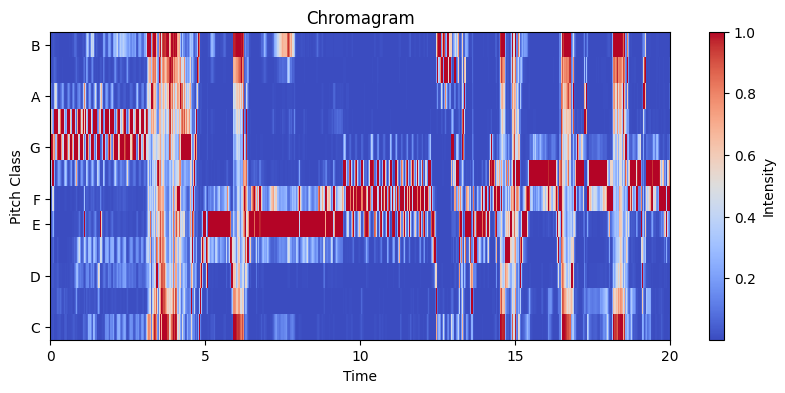

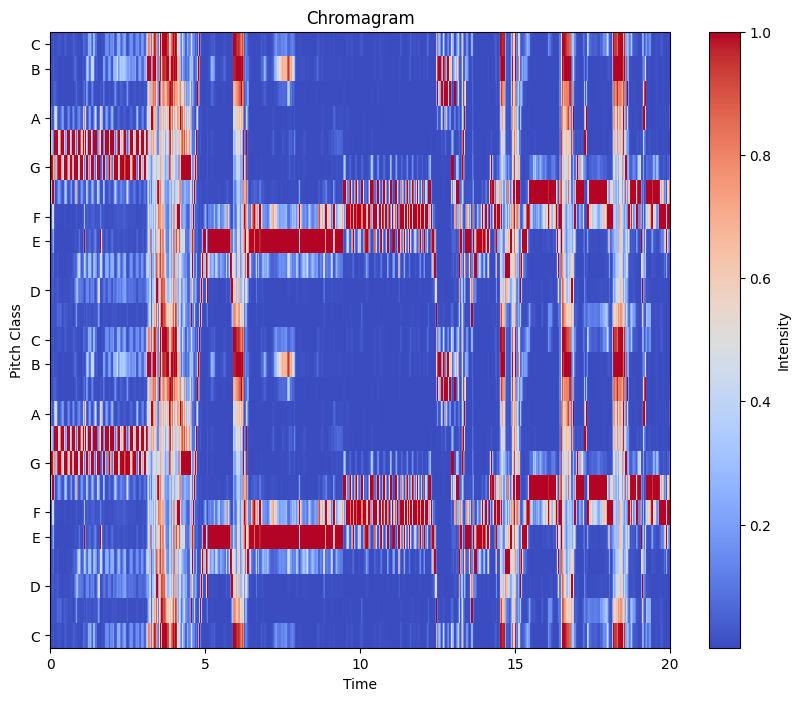

In [ ]:
def expand_chroma(chorma):
        repeat = 25 // chroma.shape[0] + 1
        expanded_chroma = np.tile(chroma, (repeat, 1))
        return expanded_chroma[:25, :]


y, sr = librosa.load("/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/Audio/Vocal_Split_20/김창환 춘향가-이별가_GMjo_40-60.wav")

chroma = librosa.feature.chroma_stft(y = y, sr = sr)

expanded_chroma = expand_chroma(chroma)

print("Chroma shape:", chroma.shape)
print("Expanded Chroma shape:", expanded_chroma.shape)

plt.figure(figsize=(10, 4))
librosa.display.specshow(chroma, x_axis='time', y_axis='chroma', cmap='coolwarm')
plt.colorbar(label='Intensity')
plt.title('Chromagram')
plt.xlabel('Time')
plt.ylabel('Pitch Class')
plt.show()

plt.figure(figsize=(10, 8))
librosa.display.specshow(expanded_chroma, x_axis='time', y_axis='chroma', cmap='coolwarm')
plt.colorbar(label='Intensity')
plt.title('Chromagram')
plt.xlabel('Time')
plt.ylabel('Pitch Class')
plt.show()